<a href="https://colab.research.google.com/github/juancpuertag/Vectorization-with-Apache-Spark/blob/main/Vectorizaci%C3%B3nSpark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vectorización de Datos en Spark: De Datos Crudos a Vectores para Machine Learning

**Objetivo del Notebook:** Entender qué es la vectorización de características (features) en Spark, por qué es un paso indispensable para el Machine Learning, y cómo implementarla usando las herramientas de la librería `spark.ml`.

### ¿Qué es y Por Qué "Vectorizar"?

Imagina que los algoritmos de Machine Learning (como la regresión logística o K-Means) son calculadoras muy avanzadas. Estas calculadoras solo entienden un idioma: los **números**. No pueden procesar texto como "Madrid" o "Femenino" directamente.

La **vectorización** es el proceso de "traducir" todas las características diversas de nuestro conjunto de datos a ese idioma universal de números, agrupándolas en un único vector por cada fila.


dataset_to_feature_vector_to_model_scaled.svg


**En este notebook aprenderemos a:**
1.  Crear un conjunto de datos de ejemplo con diferentes tipos de datos.
2.  Convertir **datos categóricos (texto)** a un formato numérico usando `StringIndexer`.
3.  Aplicar **One-Hot Encoding** para evitar que el algoritmo malinterprete los números de las categorías.
4.  Combinar todas las características numéricas en un solo vector con `VectorAssembler`.
5.  Automatizar todo el proceso de forma robusta usando un `Pipeline` de Spark ML.

In [ ]:
# =================================================================
# Paso 1: Configuración del Entorno
# =================================================================
!pip install pyspark -q

from pyspark.sql import SparkSession

# Crear la SparkSession
spark = SparkSession.builder \
    .appName("TutorialVectorizacion") \
    .getOrCreate()

print("✅ SparkSession iniciada correctamente.")

✅ SparkSession iniciada correctamente.


## 2. Creación de un Conjunto de Datos de Ejemplo

Vamos a crear un DataFrame simple que simula datos de clientes. Fíjate que tenemos una mezcla de tipos de datos:
- **`id`**: Identificador (Numérico)
- **`edad`**: Característica numérica.
- **`ciudad`**: Característica categórica en formato de texto.
- **`compro`**: Nuestra etiqueta o variable objetivo (Booleano/Numérico).

In [ ]:
# Datos de ejemplo
datos = [
    (0, 25, "Madrid", 1),
    (1, 35, "Barcelona", 0),
    (2, 22, "Sevilla", 1),
    (3, 41, "Madrid", 0),
    (4, 28, "Valencia", 1),
    (5, 33, "Barcelona", 1)
]
columnas = ["id", "edad", "ciudad", "compro"]

# Creamos el DataFrame
df = spark.createDataFrame(datos, columnas)

print("📄 DataFrame de ejemplo:")
df.show()

📄 DataFrame de ejemplo:
+---+----+---------+------+
| id|edad|   ciudad|compro|
+---+----+---------+------+
|  0|  25|   Madrid|     1|
|  1|  35|Barcelona|     0|
|  2|  22|  Sevilla|     1|
|  3|  41|   Madrid|     0|
|  4|  28| Valencia|     1|
|  5|  33|Barcelona|     1|
+---+----+---------+------+



## 3. Manejo de Datos Categóricos: `StringIndexer` y `OneHotEncoder`

Nuestro primer problema es la columna `ciudad`. Es texto, y necesitamos convertirla en números.

### Paso 3.1: `StringIndexer` - De Texto a Índices Numéricos

`StringIndexer` asigna un índice numérico único a cada categoría de texto. Por ejemplo: "Madrid" -> `0.0`, "Barcelona" -> `1.0`, etc.

vocabulary-index-sparse-feature.svg



In [ ]:
from pyspark.ml.feature import StringIndexer

# Creamos un StringIndexer
# inputCol: la columna que queremos transformar
# outputCol: el nombre de la nueva columna con los índices
indexer = StringIndexer(inputCol="ciudad", outputCol="ciudad_index")

# Entrenamos el indexer y transformamos el DataFrame
df_indexed = indexer.fit(df).transform(df)

print("📊 DataFrame con la columna 'ciudad' indexada:")
df_indexed.show()

📊 DataFrame con la columna 'ciudad' indexada:
+---+----+---------+------+------------+
| id|edad|   ciudad|compro|ciudad_index|
+---+----+---------+------+------------+
|  0|  25|   Madrid|     1|         1.0|
|  1|  35|Barcelona|     0|         0.0|
|  2|  22|  Sevilla|     1|         2.0|
|  3|  41|   Madrid|     0|         1.0|
|  4|  28| Valencia|     1|         3.0|
|  5|  33|Barcelona|     1|         0.0|
+---+----+---------+------+------------+



### Paso 3.2: `OneHotEncoder` - La Solución a la "Tiranía de los Números"

Hemos convertido el texto a números, pero ahora tenemos un problema sutil: el **orden implícito**. El algoritmo podría pensar que `Sevilla (2.0)` es "más grande" o "mejor" que `Madrid (0.0)`. Esto es incorrecto.

**One-Hot Encoding** resuelve esto. Convierte cada índice en un vector binario donde solo una posición es "caliente" (tiene un 1).

- `Madrid (0.0)` -> `[1.0, 0.0, 0.0, 0.0]`
- `Barcelona (1.0)` -> `[0.0, 1.0, 0.0, 0.0]`

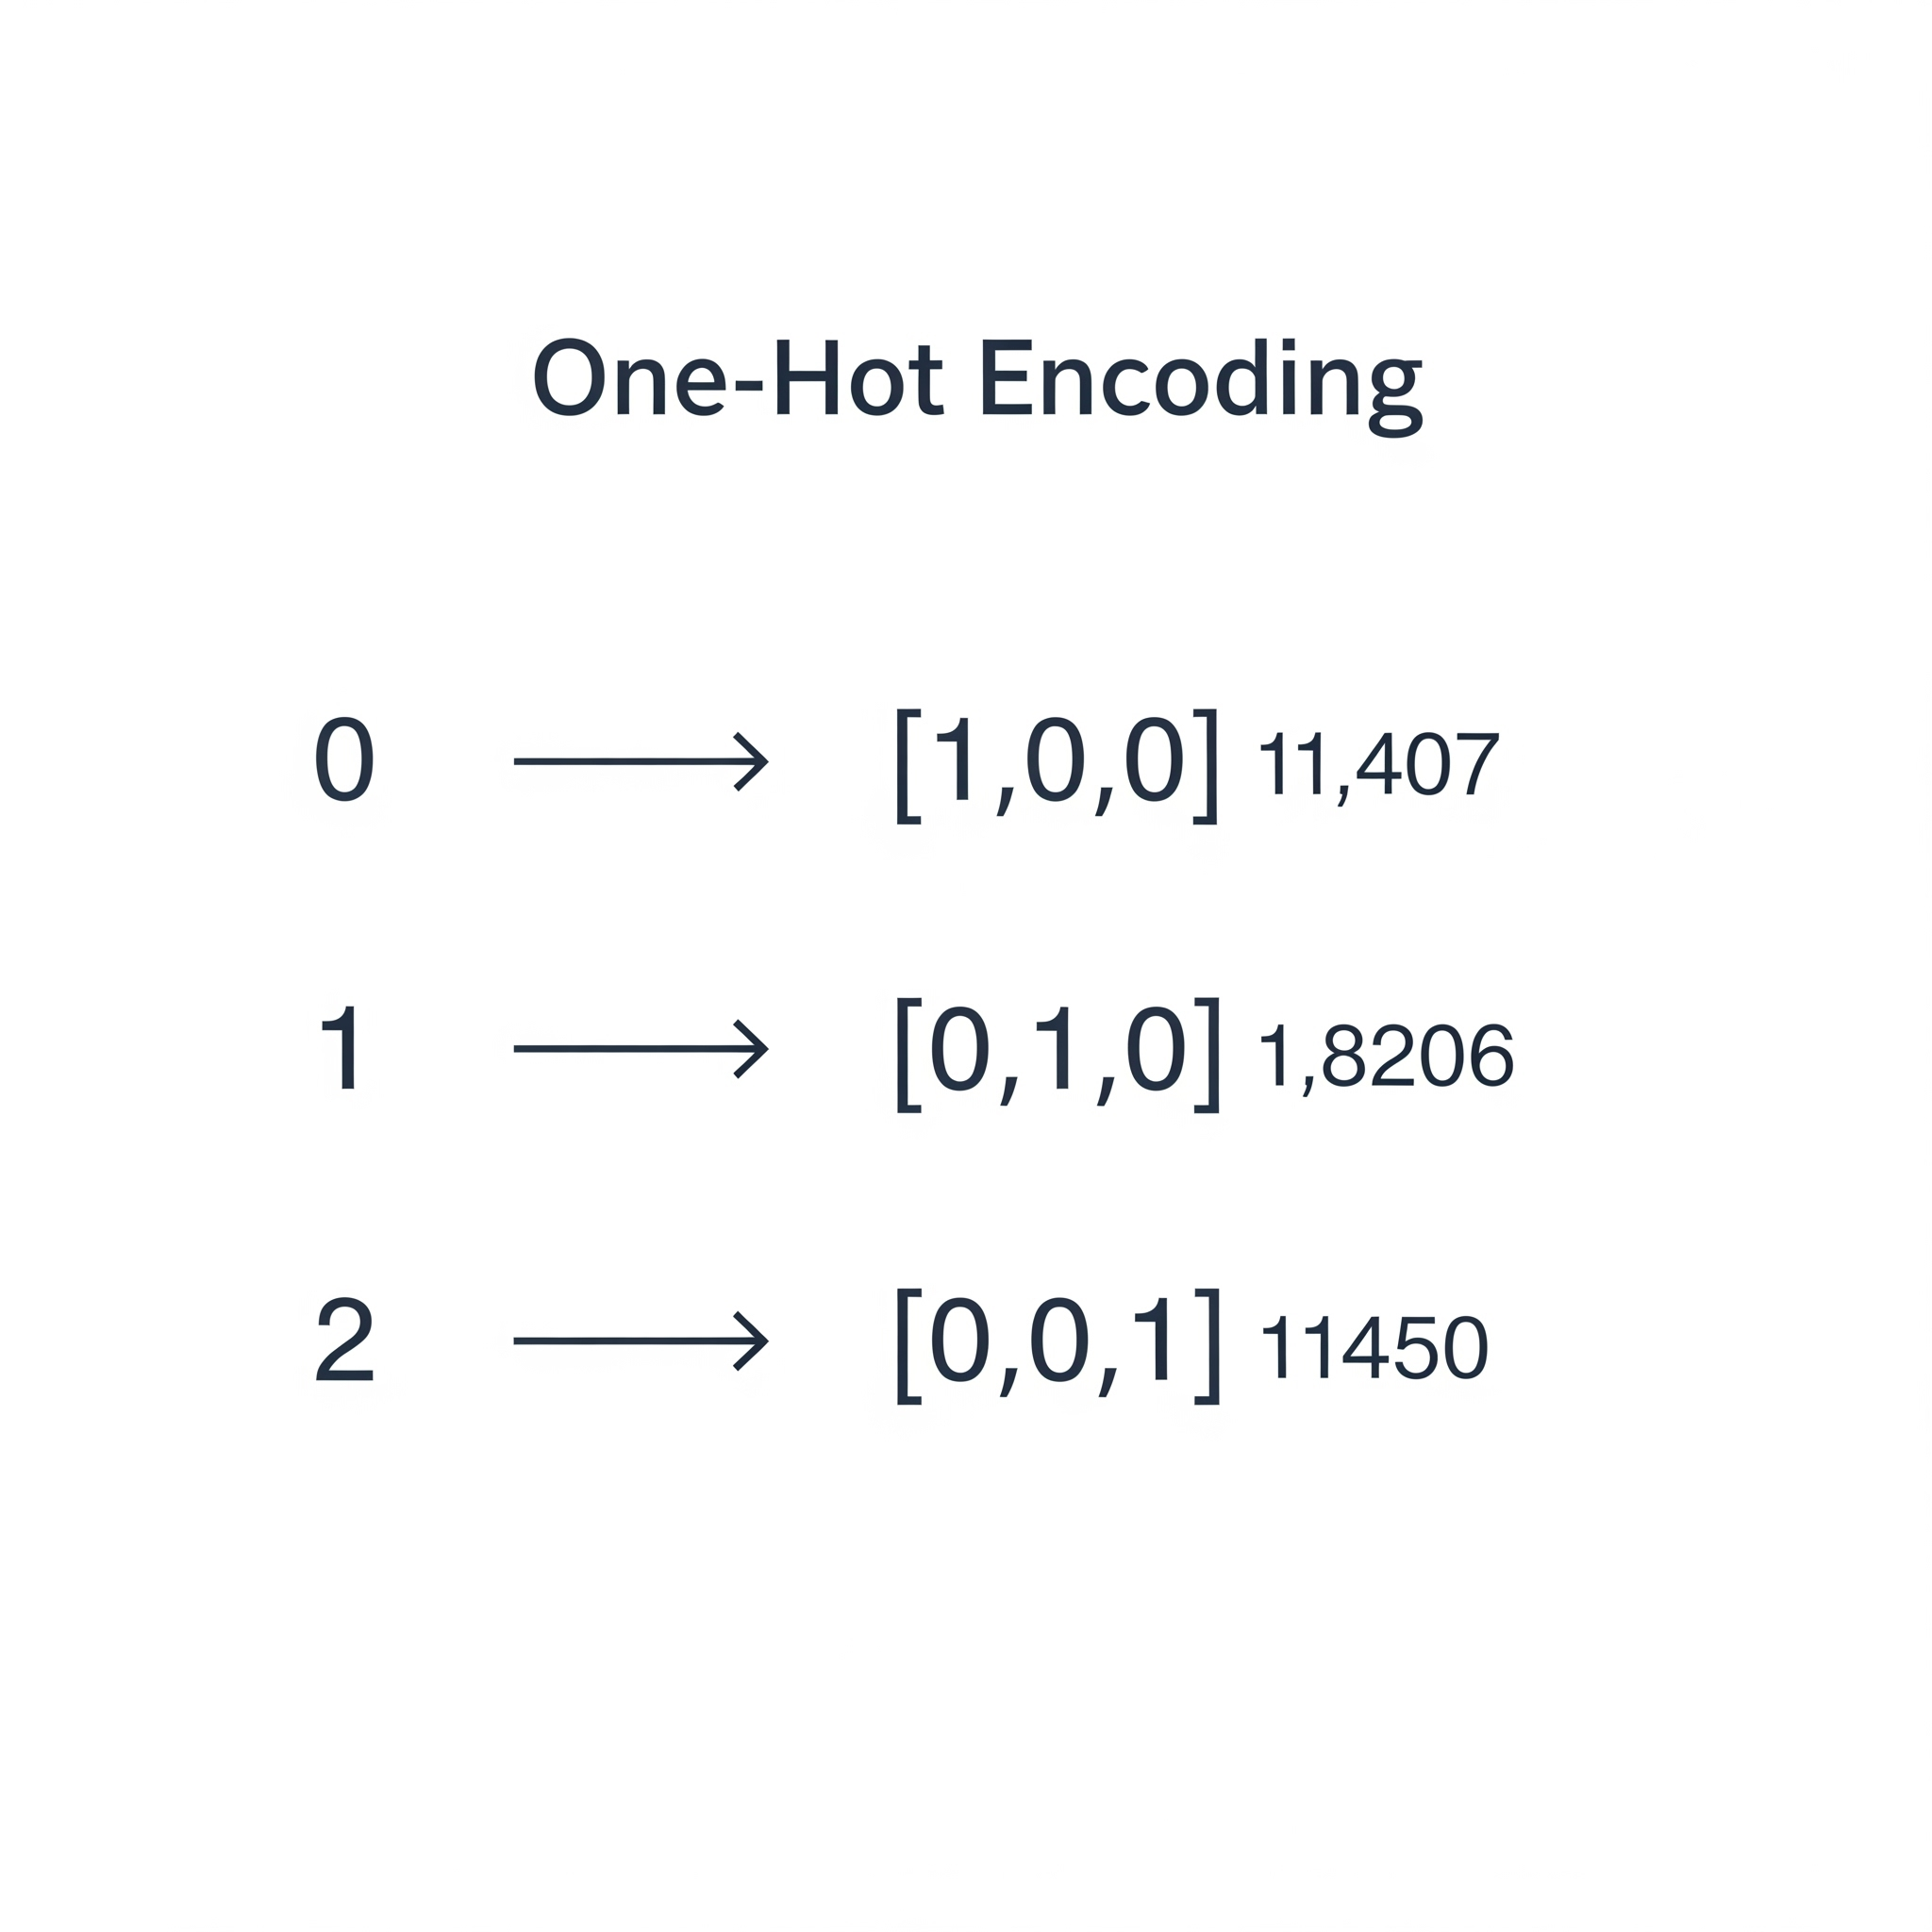


In [ ]:
from pyspark.ml.feature import OneHotEncoder

# Creamos el OneHotEncoder
# inputCol: la columna de índices que creamos antes
# outputCol: el nombre de la nueva columna con los vectores
encoder = OneHotEncoder(inputCol="ciudad_index", outputCol="ciudad_vec")

# Entrenamos el encoder y transformamos
df_encoded = encoder.fit(df_indexed).transform(df_indexed)

print("✨ DataFrame con la columna 'ciudad' codificada (One-Hot Encoded):")
df_encoded.show()

✨ DataFrame con la columna 'ciudad' codificada (One-Hot Encoded):
+---+----+---------+------+------------+-------------+
| id|edad|   ciudad|compro|ciudad_index|   ciudad_vec|
+---+----+---------+------+------------+-------------+
|  0|  25|   Madrid|     1|         1.0|(3,[1],[1.0])|
|  1|  35|Barcelona|     0|         0.0|(3,[0],[1.0])|
|  2|  22|  Sevilla|     1|         2.0|(3,[2],[1.0])|
|  3|  41|   Madrid|     0|         1.0|(3,[1],[1.0])|
|  4|  28| Valencia|     1|         3.0|    (3,[],[])|
|  5|  33|Barcelona|     1|         0.0|(3,[0],[1.0])|
+---+----+---------+------+------------+-------------+



## 4. `VectorAssembler` - Uniendo Todas las Piezas

Ahora que **todas** nuestras características de entrada (`edad` y `ciudad_vec`) son numéricas, podemos unirlas en un solo vector. `VectorAssembler` es la herramienta para este trabajo.

In [ ]:
from pyspark.ml.feature import VectorAssembler

# Especificamos las columnas de entrada que queremos combinar
# OJO: Usamos las columnas ya procesadas, no las originales
input_cols = ["edad", "ciudad_vec"]

# Creamos el VectorAssembler
# outputCol: el nombre de la columna final de características
assembler = VectorAssembler(inputCols=input_cols, outputCol="features")

# Transformamos el DataFrame para crear la columna de vectores
df_vectorized = assembler.transform(df_encoded)

print("🚀 DataFrame final con la columna 'features' vectorizada:")
# Seleccionamos solo las columnas relevantes para mayor claridad
df_vectorized.select("id", "features", "compro").show()

🚀 DataFrame final con la columna 'features' vectorizada:
+---+------------------+------+
| id|          features|compro|
+---+------------------+------+
|  0|[25.0,0.0,1.0,0.0]|     1|
|  1|[35.0,1.0,0.0,0.0]|     0|
|  2|[22.0,0.0,0.0,1.0]|     1|
|  3|[41.0,0.0,1.0,0.0]|     0|
|  4|    (4,[0],[28.0])|     1|
|  5|[33.0,1.0,0.0,0.0]|     1|
+---+------------------+------+



## 5. Automatización con `Pipeline`

Hacer todos los pasos anteriores uno por uno es tedioso y propenso a errores. Spark ML ofrece el concepto de `Pipeline` (tubería) para encadenar todas nuestras etapas de transformación en un solo flujo de trabajo.

In [ ]:
from pyspark.ml import Pipeline

# 1. Definimos las etapas de nuestra tubería en el orden correcto
indexer_pipe = StringIndexer(inputCol="ciudad", outputCol="ciudad_index")
encoder_pipe = OneHotEncoder(inputCol="ciudad_index", outputCol="ciudad_vec")
assembler_pipe = VectorAssembler(inputCols=["edad", "ciudad_vec"], outputCol="features")

# 2. Creamos el Pipeline con todas las etapas
pipeline = Pipeline(stages=[indexer_pipe, encoder_pipe, assembler_pipe])

# 3. Entrenamos ("fit") el pipeline completo con nuestros datos originales
pipeline_model = pipeline.fit(df)

# 4. Transformamos los datos con el pipeline entrenado
df_final = pipeline_model.transform(df)

print("🎉 DataFrame final, procesado completamente con el Pipeline:")
df_final.select("id", "features", "compro").show()

# Detenemos la sesión de Spark
spark.stop()

🎉 DataFrame final, procesado completamente con el Pipeline:
+---+------------------+------+
| id|          features|compro|
+---+------------------+------+
|  0|[25.0,0.0,1.0,0.0]|     1|
|  1|[35.0,1.0,0.0,0.0]|     0|
|  2|[22.0,0.0,0.0,1.0]|     1|
|  3|[41.0,0.0,1.0,0.0]|     0|
|  4|    (4,[0],[28.0])|     1|
|  5|[33.0,1.0,0.0,0.0]|     1|
+---+------------------+------+



# Vectorización de un Dataset Real con Spark ML

**Objetivo del Notebook:** Aplicar un flujo de trabajo completo de preprocesamiento y vectorización a un conjunto de datos real (el del Titanic). A diferencia de un ejemplo simple, aquí nos enfrentaremos a datos faltantes y a múltiples columnas de diferentes tipos.

El objetivo final es transformar el dataset crudo del Titanic en un formato "listo para Machine Learning", con una columna de **etiqueta (label)** y una columna de **características vectorizadas (features)**.

**Pasos que seguiremos:**
1.  Cargar el dataset del Titanic.
2.  Realizar una limpieza y exploración básica de los datos.
3.  Definir un `Pipeline` de Spark ML para procesar todas nuestras características.
4.  Convertir columnas categóricas (`Sex`, `Embarked`) a formato numérico.
5.  Combinar todas las características en un único vector.
6.  Obtener nuestro DataFrame final, listo para ser usado en un modelo.

In [ ]:
# =================================================================
# Paso 1: Configuración del Entorno
# =================================================================
!pip install pyspark -q

from pyspark.sql import SparkSession

# Crear la SparkSession
spark = SparkSession.builder \
    .appName("VectorizacionReal") \
    .getOrCreate()

print("✅ SparkSession iniciada correctamente.")

✅ SparkSession iniciada correctamente.


## 2. Carga y Exploración del Dataset

Primero, descargamos el archivo CSV y lo cargamos en un DataFrame de Spark. Luego, realizaremos una exploración inicial para entender su estructura y detectar problemas, como los valores nulos.

In [ ]:
# Descargamos el archivo CSV del Titanic
!wget -q https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv -O titanic.csv

# Cargamos el CSV en un DataFrame
df_titanic = spark.read.csv(
    "titanic.csv",
    header=True,
    inferSchema=True
)

print("📝 Esquema del DataFrame del Titanic:")
df_titanic.printSchema()

print("\n📊 Estadísticas descriptivas:")
# El conteo (count) en la columna 'Age' es menor que el total, indicando valores nulos.
df_titanic.describe().show()

📝 Esquema del DataFrame del Titanic:
root
 |-- PassengerId: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Pclass: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Ticket: string (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Cabin: string (nullable = true)
 |-- Embarked: string (nullable = true)


📊 Estadísticas descriptivas:
+-------+-----------------+-------------------+------------------+--------------------+------+------------------+------------------+-------------------+------------------+-----------------+-----+--------+
|summary|      PassengerId|           Survived|            Pclass|                Name|   Sex|               Age|             SibSp|              Parch|            Ticket|             Fare|Cabin|Embarked|
+-------+-----------------+-------------------+-------------

## 3. Limpieza de Datos

Los datos reales rara vez son perfectos. Nuestro análisis descriptivo mostró que la columna `Age` (Edad) tiene valores nulos. Un algoritmo de Machine Learning no puede trabajar con datos faltantes, así que debemos manejarlos.

Una estrategia común es **imputar** los valores faltantes, es decir, rellenarlos con un valor calculado. En este caso, rellenaremos las edades faltantes con la **edad promedio** de todos los pasajeros.

In [ ]:
from pyspark.sql.functions import avg

# Calculamos la edad promedio
mean_age = df_titanic.select(avg("Age")).first()[0]
mean_age = round(mean_age) # Redondeamos para tener un número entero

print(f"La edad promedio es: {mean_age} años.")

# Rellenamos los valores nulos en la columna 'Age' con el promedio
df_titanic_clean = df_titanic.na.fill({"Age": mean_age})

# También hay 2 filas con 'Embarked' nulo, las eliminaremos ya que son muy pocas.
df_titanic_clean = df_titanic_clean.na.drop(subset=["Embarked"])

print("\nVerificación: El conteo de 'Age' ahora debería coincidir con el total de filas.")
df_titanic_clean.describe().show()

La edad promedio es: 30 años.

Verificación: El conteo de 'Age' ahora debería coincidir con el total de filas.
+-------+------------------+-------------------+------------------+--------------------+------+------------------+------------------+-------------------+------------------+-----------------+-----+--------+
|summary|       PassengerId|           Survived|            Pclass|                Name|   Sex|               Age|             SibSp|              Parch|            Ticket|             Fare|Cabin|Embarked|
+-------+------------------+-------------------+------------------+--------------------+------+------------------+------------------+-------------------+------------------+-----------------+-----+--------+
|  count|               889|                889|               889|                 889|   889|               889|               889|                889|               889|              889|  202|     889|
|   mean|             446.0|0.38245219347581555|2.311586051743532

## 4. Construcción del Pipeline de Vectorización

Ahora que nuestros datos están limpios, construiremos un `Pipeline` para realizar todas las transformaciones necesarias para la vectorización.

**Nuestra estrategia será:**
1.  **Identificar las columnas:** Separaremos las columnas categóricas de las numéricas que usaremos como características.
2.  **Transformar Categóricas:** Usaremos `StringIndexer` y `OneHotEncoder` para las columnas `Sex` y `Embarked`.
3.  **Ensamblar el Vector:** Usaremos `VectorAssembler` para unir todas nuestras características procesadas (las numéricas originales y las categóricas ya codificadas) en un solo vector.

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

# 1. Identificar las columnas
categorical_cols = ["Sex", "Embarked"]
# Columnas numéricas que usaremos como características
numeric_cols = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

# 2. Crear las etapas de transformación para las columnas categóricas
# Usaremos un bucle para crear un StringIndexer y OneHotEncoder para cada columna categórica
stages = []
for col in categorical_cols:
    # Convertir texto a índices numéricos
    indexer = StringIndexer(inputCol=col, outputCol=f"{col}_index")
    # Convertir índices a vectores One-Hot
    encoder = OneHotEncoder(inputCol=f"{col}_index", outputCol=f"{col}_vec")
    stages += [indexer, encoder]

# 3. Crear la etapa del VectorAssembler
# Las columnas de entrada serán las numéricas y las nuevas columnas vectorizadas de OneHotEncoder
assembler_inputs = [f"{col}_vec" for col in categorical_cols] + numeric_cols
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

stages += [assembler]

# 4. Crear el Pipeline completo
pipeline = Pipeline(stages=stages)

## 5. Ejecutar el Pipeline y Obtener el Dataset Final

Ahora, entrenaremos nuestro `Pipeline` con los datos limpios y luego los transformaremos. El resultado será un nuevo DataFrame con la columna `features` que contiene los vectores listos para el Machine Learning. También renombraremos la columna `Survived` a `label`, que es el nombre estándar que esperan los algoritmos de Spark ML.

In [ ]:
# Entrenamos el pipeline con nuestros datos
pipeline_model = pipeline.fit(df_titanic_clean)

# Transformamos los datos
df_final = pipeline_model.transform(df_titanic_clean)

# Renombramos la columna 'Survived' a 'label'
df_final = df_final.withColumnRenamed("Survived", "label")

print("🚀 ¡Dataset final listo para Machine Learning!")
# Mostramos solo las columnas de interés: el identificador, la etiqueta y el vector de características
df_final.select("PassengerId", "label", "features").show(truncate=False)

# Detenemos la sesión de Spark para liberar recursos
spark.stop()

🚀 ¡Dataset final listo para Machine Learning!
+-----------+-----+--------------------------------------+
|PassengerId|label|features                              |
+-----------+-----+--------------------------------------+
|1          |0    |[1.0,1.0,0.0,3.0,22.0,1.0,0.0,7.25]   |
|2          |1    |[0.0,0.0,1.0,1.0,38.0,1.0,0.0,71.2833]|
|3          |1    |(8,[1,3,4,7],[1.0,3.0,26.0,7.925])    |
|4          |1    |[0.0,1.0,0.0,1.0,35.0,1.0,0.0,53.1]   |
|5          |0    |[1.0,1.0,0.0,3.0,35.0,0.0,0.0,8.05]   |
|6          |0    |(8,[0,3,4,7],[1.0,3.0,30.0,8.4583])   |
|7          |0    |[1.0,1.0,0.0,1.0,54.0,0.0,0.0,51.8625]|
|8          |0    |[1.0,1.0,0.0,3.0,2.0,3.0,1.0,21.075]  |
|9          |1    |[0.0,1.0,0.0,3.0,27.0,0.0,2.0,11.1333]|
|10         |1    |[0.0,0.0,1.0,2.0,14.0,1.0,0.0,30.0708]|
|11         |1    |[0.0,1.0,0.0,3.0,4.0,1.0,1.0,16.7]    |
|12         |1    |(8,[1,3,4,7],[1.0,1.0,58.0,26.55])    |
|13         |0    |[1.0,1.0,0.0,3.0,20.0,0.0,0.0,8.05]   |
|14       